# GoldRegime X - Iteration 2: Fast Sensitivity Plateau Lab (M5/M15)

This notebook replaces Optuna with a robust and faster Grid Sensitivity Plateau workflow:

1. Feature engineering + Triple-Barrier labeling
2. CPCV with Purge + Embargo
3. HMM + XGBoost composite model
4. Coarse-to-fine parameter search with parallel execution
5. Plateau-center selection
6. OOS holdout and cost stress tests

Goal:
Find stable parameter regions for M5/M15 that survive out-of-sample and transaction-cost stress.

In [1]:
import os
import sys
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Iterator, Tuple
import itertools
import math
import time

# ---- Project root bootstrap (critical for joblib child processes on Windows) ----
_here = Path.cwd().resolve()
if _here.name.lower() == "notebooks":
    _project_root = _here.parent
else:
    _project_root = _here

os.chdir(_project_root)

_project_root_str = str(_project_root)
if _project_root_str not in sys.path:
    sys.path.insert(0, _project_root_str)

_prev_py_path = os.environ.get("PYTHONPATH", "")
if _prev_py_path:
    if _project_root_str not in _prev_py_path.split(os.pathsep):
        os.environ["PYTHONPATH"] = _project_root_str + os.pathsep + _prev_py_path
else:
    os.environ["PYTHONPATH"] = _project_root_str

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import xgboost as xgb

from src.backtester import vectorized_backtest
from src.trade_lifecycle import config_for_tf
from src.risk_manager import BROKER_CONFIGS

try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except Exception:
    JOBLIB_OK = False

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Working directory:", os.getcwd())
print("Project root:", _project_root_str)
print("PYTHONPATH:", os.environ.get("PYTHONPATH", ""))
print("joblib available:", JOBLIB_OK)

Working directory: C:\GoldRegime_X
Project root: C:\GoldRegime_X
PYTHONPATH: C:\GoldRegime_X
joblib available: True


In [2]:
# -----------------------------
# Global config
# -----------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Strategy TF contract
EXEC_TF = "M5"
TREND_TF = "M15"

# Account and execution assumptions
INITIAL_BALANCE_CENTS = 1500.0
SPREAD_CAP_POINTS = 40.0          # 40 points max = 4.0 pips
STOP_LOSS_PIPS = 15.0
RR_MULT = 2.0
MAX_POSITIONS_PER_CYCLE = 2
LOT_CYCLE_SMALL = [0.01, 0.02]    # for 15 USD account
BALANCE_SCALE_THRESHOLD_CENTS = 5000.0  # 50 USD

# Runtime controls
N_JOBS = max(1, (os.cpu_count() or 4) - 1)

# CPCV-like controls for strategy parameter search
COARSE_CPCV_N_BLOCKS = 4
COARSE_CPCV_K_VAL = 2
FINE_CPCV_N_BLOCKS = 4
FINE_CPCV_K_VAL = 2
EMBARGO_HOURS = 24

# Holdout split
HOLDOUT_FRAC = 0.20

BARS_PER_DAY = {"M15": 96, "M5": 288}
BARS_PER_YEAR = {"M15": 252 * 96, "M5": 252 * 288}

# Source paths
TF_TO_XAU_RAW = {
    "M15": Path("data/raw/XAU_15m_data.csv"),
    "M5": Path("data/raw/XAU_5m_data.csv"),
}

print("Execution TF:", EXEC_TF)
print("Trend TF:", TREND_TF)
print("Initial balance (cents):", INITIAL_BALANCE_CENTS)
print("Spread cap (points):", SPREAD_CAP_POINTS)
print("CPCV paths coarse:", math.comb(COARSE_CPCV_N_BLOCKS, COARSE_CPCV_K_VAL))
print("CPCV paths fine:", math.comb(FINE_CPCV_N_BLOCKS, FINE_CPCV_K_VAL))

Execution TF: M5
Trend TF: M15
Initial balance (cents): 1500.0
Spread cap (points): 40.0
CPCV paths coarse: 6
CPCV paths fine: 6


In [3]:
# ---------------------------------------------------------
# INGESTION LAYER: Import validated parameters from Strategy Tester
# ---------------------------------------------------------
import json

def load_optimized_strategies(filepath="reports/strategy_winners_for_explorer.csv", max_dd=25.0):
    try:
        winners_df = pd.read_csv(filepath)
        print(f"Loaded {len(winners_df)} candidate strategies from bridge.")
    except FileNotFoundError:
        raise FileNotFoundError(f"Bridge file {filepath} not found. Run Strategy_Tester.ipynb first.")

    strict_winners = winners_df[winners_df["max_drawdown"] <= max_dd].copy()
    best_params_by_tf = {}

    for tf in ["M15", "M5"]:
        tf_df = strict_winners[strict_winners["timeframe"] == tf]
        if tf_df.empty:
            print(f"WARNING: No strategies for {tf} survived the {max_dd}% DD filter.")
            best_params_by_tf[tf] = None
            continue

        top_row = tf_df.sort_values("robust_score", ascending=False).iloc[0]
        params_dict = json.loads(top_row["parameter_set"])

        best_params_by_tf[tf] = {
            "strategy_name": top_row["strategy_name"],
            "exit_model": top_row["exit_model"],
            "parameters": params_dict,
            "expected_pf": top_row["profit_factor"],
            "expected_dd": top_row["max_drawdown"],
        }
        print(f"Acquired {tf} Baseline -> PF: {top_row['profit_factor']:.2f} | DD: {top_row['max_drawdown']:.2f}%")

    return best_params_by_tf

ML_TARGET_PARAMS = load_optimized_strategies(max_dd=25.0)

if ML_TARGET_PARAMS.get(EXEC_TF) is None:
    raise RuntimeError(f"No {EXEC_TF} baseline survived 25% DD filter. Re-run Strategy Tester.")


Loaded 2 candidate strategies from bridge.
Acquired M15 Baseline -> PF: 1.23 | DD: 24.00%
Acquired M5 Baseline -> PF: 1.18 | DD: 24.00%


In [4]:
# -----------------------------
# Data loading helpers
# -----------------------------

def _normalize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c.lower(): c for c in df.columns}
    rename_map = {}
    if "open" in cols:
        rename_map[cols["open"]] = "Open"
    if "high" in cols:
        rename_map[cols["high"]] = "High"
    if "low" in cols:
        rename_map[cols["low"]] = "Low"
    if "close" in cols:
        rename_map[cols["close"]] = "Close"
    if "volume" in cols:
        rename_map[cols["volume"]] = "Volume"

    out = df.rename(columns=rename_map)
    need = ["Open", "High", "Low", "Close"]
    missing = [c for c in need if c not in out.columns]
    if missing:
        raise ValueError(f"Missing OHLC columns: {missing}")
    return out

def read_xau_raw(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, sep=";")
    if "Date" not in df.columns:
        raise ValueError(f"Date column missing in {path}")

    df["Date"] = pd.to_datetime(df["Date"], format="%Y.%m.%d %H:%M", errors="coerce")
    df = df.dropna(subset=["Date"]).set_index("Date").sort_index()
    df = _normalize_ohlcv(df)
    return df

def read_master_close(path: Path) -> pd.Series:
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
    if "Close" in df.columns:
        s = df["Close"].astype(float)
    elif "close" in df.columns:
        s = df["close"].astype(float)
    else:
        raise ValueError(f"Close column missing in {path}")
    return s

def load_panel(tf: str) -> pd.DataFrame:
    tf = tf.upper()
    xau = read_xau_raw(TF_TO_XAU_RAW[tf])

    out = xau.copy()

    # Optional external series maps (if defined in other notebook variants).
    xag_map = globals().get("TF_TO_XAG_MASTER", {})
    xti_map = globals().get("TF_TO_XTI_MASTER", {})

    if isinstance(xag_map, dict) and tf in xag_map and Path(xag_map[tf]).exists():
        xag = read_master_close(Path(xag_map[tf])).rename("XAG_Close")
        out["XAG_Close"] = xag.reindex(out.index).ffill()
    else:
        # Fallback keeps old feature functions from breaking.
        out["XAG_Close"] = out["Close"].astype(float)

    if isinstance(xti_map, dict) and tf in xti_map and Path(xti_map[tf]).exists():
        xti = read_master_close(Path(xti_map[tf])).rename("XTI_Close")
        out["XTI_Close"] = xti.reindex(out.index).ffill()
    else:
        out["XTI_Close"] = out["Close"].astype(float)

    out = out.dropna(subset=["XAG_Close", "XTI_Close"]).copy()
    return out

In [5]:
# -----------------------------
# Feature engineering + labels
# -----------------------------

def ema(series: pd.Series, period: int) -> pd.Series:
    return series.ewm(span=int(period), adjust=False, min_periods=int(period)).mean()

def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return (100.0 - (100.0 / (1.0 + rs))).fillna(50.0)

def true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr

def atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()

def adx(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = up_move.where((up_move > down_move) & (up_move > 0.0), 0.0)
    minus_dm = down_move.where((down_move > up_move) & (down_move > 0.0), 0.0)
    atr_v = atr(high, low, close, period=period).replace(0.0, np.nan)
    plus_di = 100.0 * plus_dm.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean() / atr_v
    minus_di = 100.0 * minus_dm.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean() / atr_v
    dx = 100.0 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0.0, np.nan)
    return dx.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean().fillna(0.0)

def synth_vix_zscore(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 22) -> pd.Series:
    roll_max = high.rolling(period, min_periods=period).max()
    vix_fix = ((roll_max - low) / roll_max) * 100.0
    mu = vix_fix.rolling(period, min_periods=period).mean()
    sd = vix_fix.rolling(period, min_periods=period).std().replace(0, np.nan)
    return ((vix_fix - mu) / sd).rename("synth_vix_zscore")

def add_session_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    hour = out.index.hour
    london = (hour >= 7) & (hour < 16)
    ny = (hour >= 13) & (hour < 21)
    overlap = (hour >= 13) & (hour < 16)
    out["session"] = np.where(overlap, "OVERLAP", np.where(london, "LONDON", np.where(ny, "NEW_YORK", "ASIA")))
    out["session_mask_none"] = True
    out["session_mask_london"] = london
    out["session_mask_ny"] = ny
    out["session_mask_london_ny"] = london | ny
    return out

def build_features(exec_panel: pd.DataFrame, trend_panel: pd.DataFrame, exec_tf: str) -> pd.DataFrame:
    exec_tf = exec_tf.upper()
    if exec_tf not in ("M5", "M15"):
        raise ValueError(f"Unsupported timeframe: {exec_tf}")

    exec_df = exec_panel.copy()
    trend_df = trend_panel.copy()

    # ML features on execution bars
    exec_df["log_return"] = np.log(exec_df["Close"] / exec_df["Close"].shift(1))
    exec_df["xag_log_return"] = np.log(exec_df["XAG_Close"] / exec_df["XAG_Close"].shift(1))
    exec_df["xti_log_return"] = np.log(exec_df["XTI_Close"] / exec_df["XTI_Close"].shift(1))

    exec_df["gold_silver_ratio"] = exec_df["Close"] / exec_df["XAG_Close"]
    exec_df["gold_oil_ratio"] = exec_df["Close"] / exec_df["XTI_Close"]

    rw = 64
    gs_m = exec_df["gold_silver_ratio"].rolling(rw, min_periods=rw).mean()
    gs_s = exec_df["gold_silver_ratio"].rolling(rw, min_periods=rw).std().replace(0, np.nan)
    go_m = exec_df["gold_oil_ratio"].rolling(rw, min_periods=rw).mean()
    go_s = exec_df["gold_oil_ratio"].rolling(rw, min_periods=rw).std().replace(0, np.nan)

    exec_df["gold_silver_ratio_z"] = ((exec_df["gold_silver_ratio"] - gs_m) / gs_s).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    exec_df["gold_oil_ratio_z"] = ((exec_df["gold_oil_ratio"] - go_m) / go_s).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = true_range(exec_df["High"], exec_df["Low"], exec_df["Close"])
    exec_df["atr_20"] = tr.rolling(20, min_periods=20).mean()
    exec_df["atr_normalized"] = exec_df["atr_20"] / exec_df["Close"]
    exec_df["volatility_20"] = exec_df["log_return"].rolling(20, min_periods=20).std()
    exec_df["synth_vix_zscore"] = synth_vix_zscore(exec_df["High"], exec_df["Low"], exec_df["Close"], period=22)

    exec_df["hour"] = exec_df.index.hour
    exec_df["hour_sin"] = np.sin(2 * np.pi * exec_df["hour"] / 24.0)
    exec_df["hour_cos"] = np.cos(2 * np.pi * exec_df["hour"] / 24.0)

    # Strategy Tester structural indicators on execution TF
    exec_df["rsi5"] = rsi(exec_df["Close"], period=5)
    exec_df["atr14"] = atr(exec_df["High"], exec_df["Low"], exec_df["Close"], period=14)
    exec_df["atr100"] = atr(exec_df["High"], exec_df["Low"], exec_df["Close"], period=100)
    exec_df["atr_expansion"] = exec_df["atr14"] / exec_df["atr100"].replace(0.0, np.nan)

    # M15 trend frame (true higher-TF context)
    trend_df["m15_ema50"] = ema(trend_df["Close"], period=50)
    trend_df["m15_ema200"] = ema(trend_df["Close"], period=200)
    trend_df["m15_adx14"] = adx(trend_df["High"], trend_df["Low"], trend_df["Close"], period=14)

    if exec_tf == "M5":
        ex = exec_df.reset_index().rename(columns={exec_df.index.name or "index": "time"})
        tr = trend_df.reset_index().rename(columns={trend_df.index.name or "index": "time"})
        merged = pd.merge_asof(
            ex.sort_values("time"),
            tr[["time", "m15_ema50", "m15_ema200", "m15_adx14"]].sort_values("time"),
            on="time",
            direction="backward",
        ).set_index("time")
    else:
        merged = exec_df.copy()
        merged["m15_ema50"] = trend_df["m15_ema50"].reindex(merged.index)
        merged["m15_ema200"] = trend_df["m15_ema200"].reindex(merged.index)
        merged["m15_adx14"] = trend_df["m15_adx14"].reindex(merged.index)

    merged = add_session_features(merged)
    merged["spread"] = SPREAD_CAP_POINTS

    is_trend = (merged["m15_adx14"] > 20.0) & (merged["atr_expansion"] < 1.3)
    is_shock = merged["atr_expansion"] >= 1.3
    merged["regime_str"] = np.where(is_shock, "SHOCK", np.where(is_trend, "TREND", "MR"))
    merged["regime_code"] = np.where(is_shock, 2, np.where(is_trend, 1, 3)).astype(np.int32)

    keep = [
        "Open", "High", "Low", "Close",
        "log_return", "xag_log_return", "xti_log_return",
        "gold_silver_ratio_z", "gold_oil_ratio_z",
        "atr_20", "atr_normalized", "volatility_20",
        "synth_vix_zscore", "hour_sin", "hour_cos",
        "rsi5", "atr14", "atr100", "atr_expansion",
        "m15_ema50", "m15_ema200", "m15_adx14",
        "spread", "regime_str", "regime_code",
        "session_mask_none", "session_mask_london", "session_mask_ny", "session_mask_london_ny",
    ]
    merged = merged[keep].dropna().copy()
    return triple_barrier(merged, exec_tf)

def triple_barrier(df: pd.DataFrame, tf: str, atr_mult: float = 1.5) -> pd.DataFrame:
    out = df.copy()
    horizon = 12 if tf.upper() == "M5" else 4

    close = out["Close"].to_numpy()
    high = out["High"].to_numpy()
    low = out["Low"].to_numpy()
    atr_v = out["atr_20"].to_numpy()

    n = len(out)
    label = np.zeros(n, dtype=np.int8)
    event_end_pos = np.arange(n, dtype=np.int32)

    for i in range(n):
        if i + 1 >= n or np.isnan(atr_v[i]):
            label[i] = 0
            event_end_pos[i] = i
            continue

        up = close[i] + atr_mult * atr_v[i]
        dn = close[i] - atr_mult * atr_v[i]
        end_i = min(n - 1, i + horizon)

        hit = 0
        hit_pos = end_i
        for j in range(i + 1, end_i + 1):
            up_hit = high[j] >= up
            dn_hit = low[j] <= dn

            if up_hit and dn_hit:
                hit = 0
                hit_pos = j
                break
            if up_hit:
                hit = 1
                hit_pos = j
                break
            if dn_hit:
                hit = -1
                hit_pos = j
                break

        label[i] = hit
        event_end_pos[i] = hit_pos

    out["tb_label"] = label
    out["event_end_pos"] = event_end_pos
    out["event_end_time"] = out.index[event_end_pos]
    return out

LABEL_COLS = {"tb_label", "event_end_pos", "event_end_time"}

def hmm_feature_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c not in LABEL_COLS and df[c].dtype != object]


In [6]:
# -----------------------------
# CPCV splitter with Purge + Embargo
# -----------------------------

@dataclass
class CPCVPurgedEmbargo:
    n_blocks: int = 6
    k_val_blocks: int = 2
    embargo_bars: int = 96

    def split(self, n: int, event_end_pos: np.ndarray) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        all_idx = np.arange(n, dtype=np.int32)
        blocks = [np.array(x, dtype=np.int32) for x in np.array_split(all_idx, self.n_blocks)]
        block_ranges = [(b[0], b[-1]) for b in blocks if len(b) > 0]

        block_ids = list(range(len(blocks)))
        for combo in itertools.combinations(block_ids, self.k_val_blocks):
            val_blocks = [blocks[c] for c in combo]
            val_idx = np.sort(np.concatenate(val_blocks))

            val_ranges = [block_ranges[c] for c in combo]
            train_mask = np.ones(n, dtype=bool)
            train_mask[val_idx] = False
            train_idx = np.where(train_mask)[0]

            # Purge overlap with label windows
            keep = np.ones(len(train_idx), dtype=bool)
            for k, i in enumerate(train_idx):
                e_i = int(event_end_pos[i])
                for v_start, v_end in val_ranges:
                    if (i <= v_end) and (e_i >= v_start):
                        keep[k] = False
                        break
            train_idx = train_idx[keep]

            # Embargo after each validation range
            embargo_mask = np.zeros(n, dtype=bool)
            for _, v_end in val_ranges:
                e_s = v_end + 1
                e_e = min(n - 1, v_end + self.embargo_bars)
                if e_s <= e_e:
                    embargo_mask[e_s:e_e + 1] = True
            train_idx = train_idx[~embargo_mask[train_idx]]

            if len(train_idx) == 0 or len(val_idx) == 0:
                continue

            yield np.sort(train_idx), val_idx

In [7]:
# -----------------------------
# HMM + XGBoost composite
# -----------------------------

class HMMXGBComposite(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_components=3,
        max_depth=4,
        learning_rate=0.05,
        n_estimators=200,
        random_state=42,
    ):
        self.n_components = int(n_components)
        self.max_depth = int(max_depth)
        self.learning_rate = float(learning_rate)
        self.n_estimators = int(n_estimators)
        self.random_state = int(random_state)

        self.hmm = None
        self.hmm_scaler = None
        self.xgb = None
        self.feature_names_ = None
        self.hmm_features_ = None

        self.y_to_cls_ = {-1: 0, 0: 1, 1: 2}
        self.cls_to_y_ = {0: -1, 1: 0, 2: 1}

    def fit(self, X: pd.DataFrame, y: pd.Series, hmm_features: list[str]):
        X = X.copy()
        y = pd.Series(y).astype(int)

        self.feature_names_ = list(X.columns)
        self.hmm_features_ = list(hmm_features)

        X_hmm = X[self.hmm_features_].to_numpy(dtype=float)
        self.hmm_scaler = StandardScaler()
        X_hmm = self.hmm_scaler.fit_transform(X_hmm)

        self.hmm = GaussianHMM(
            n_components=self.n_components,
            covariance_type="full",
            n_iter=120,
            random_state=self.random_state,
        )
        self.hmm.fit(X_hmm)
        regimes = self.hmm.predict(X_hmm)
        reg_oh = np.eye(self.n_components, dtype=float)[regimes]

        X_xgb = np.hstack([X.to_numpy(dtype=float), reg_oh])
        y_cls = y.map(self.y_to_cls_).to_numpy(dtype=int)

        self.xgb = xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=self.random_state,
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=1,
        )
        self.xgb.fit(X_xgb, y_cls)
        return self

    def _augment(self, X: pd.DataFrame) -> np.ndarray:
        X = X[self.feature_names_].copy()
        X_hmm = X[self.hmm_features_].to_numpy(dtype=float)
        X_hmm = self.hmm_scaler.transform(X_hmm)
        regimes = self.hmm.predict(X_hmm)
        reg_oh = np.eye(self.n_components, dtype=float)[regimes]
        return np.hstack([X.to_numpy(dtype=float), reg_oh])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        X_aug = self._augment(X)
        cls = self.xgb.predict(X_aug).astype(int)
        y = np.array([self.cls_to_y_[int(c)] for c in cls], dtype=np.int8)
        return y

    def predict_proba_raw(self, X: pd.DataFrame) -> np.ndarray:
        X_aug = self._augment(X)
        return self.xgb.predict_proba(X_aug)

In [8]:
# -----------------------------
# Numba Engine + ML Trend Pullback Wrapper (imported from Strategy Tester)
# -----------------------------
from numba import njit

# Position split constants (required by numba engine body)
POSITION_A = 0.01
POSITION_B = 0.02
LEG_C_ATR_STOP = 0.5
LEG_C_ATR_TARGET = 0.5

PIP_SIZE_PRICE = 0.10
PIP_VALUE_CENTS_PER_1LOT = 100.0
SLIPPAGE_PIPS = 0.30
COMMISSION_CENTS_PER_TRADE = 0.0

@njit(cache=True)
def _run_backtest_numba(
    sig, high, low, close, spread, atr14, regime_code, time_minutes, 
    entry_atr_stop, entry_atr_target, leg_a_atr_target, exit_mode_code, 
    time_stop_minutes, trail_mult, initial_balance, pip_size_price, 
    pip_value_per_1lot, slippage_pips, spread_cap_points, commission_cents, is_m5
):
    n = sig.shape[0]
    max_trades = n * 3

    trade_entry_idx = np.empty(max_trades, dtype=np.int64)
    trade_exit_idx = np.empty(max_trades, dtype=np.int64)
    trade_leg = np.empty(max_trades, dtype=np.int8)
    trade_side = np.empty(max_trades, dtype=np.int8)
    trade_entry_px = np.empty(max_trades, dtype=np.float64)
    trade_exit_px = np.empty(max_trades, dtype=np.float64)
    trade_move_pips = np.empty(max_trades, dtype=np.float64)
    trade_pnl_cents = np.empty(max_trades, dtype=np.float64)
    trade_reason = np.empty(max_trades, dtype=np.int8)
    trade_entry_regime = np.empty(max_trades, dtype=np.int32)

    eq = np.empty(max_trades + 1, dtype=np.float64)
    eq[0] = initial_balance
    eq_count = 1

    legs = np.zeros((3, 7), dtype=np.float64)
    trade_count = 0
    balance = initial_balance
    active_trade_regime = 0
    leg_a_profit_hit = 0
    leg_b_profit_hit = 0

    enable_fixed_tp = exit_mode_code in (0, 2)
    enable_mr = exit_mode_code in (1, 2, 3, 4)
    enable_time_stop = exit_mode_code == 4
    enable_trail = exit_mode_code == 4

    for i in range(n):
        s = int(sig[i])
        current_regime = int(regime_code[i])

        is_flat = (legs[0, 0] == 0.0 and legs[1, 0] == 0.0 and legs[2, 0] == 0.0)
        leg_a_closed_b_open = (legs[0, 0] == 0.0 and legs[1, 0] == 1.0 and leg_a_profit_hit == 1)
        leg_b_closed_a_open = (legs[1, 0] == 0.0 and legs[0, 0] == 1.0 and leg_b_profit_hit == 1)
        can_scale_in = (legs[2, 0] == 0.0 and (leg_a_closed_b_open or leg_b_closed_a_open))

        # ENTRY & SCALE-IN LOGIC
        if (is_flat or can_scale_in) and s != 0:
            sp_points = spread[i]
            atr_now = atr14[i]
            
            effective_spread = (sp_points / 10.0) * pip_size_price
            if np.isfinite(atr_now) and atr_now > 0.0 and effective_spread <= (0.8 * atr_now):
                side = 1 if s > 0 else -1

                if can_scale_in:
                    runner_idx = 1 if leg_a_closed_b_open else 0
                    if side != int(legs[runner_idx, 2]):
                        continue 

                spread_price = effective_spread
                slippage_price = slippage_pips * pip_size_price
                close_px = close[i]

                # RISK MANAGEMENT: Dynamic Asymmetric Guard Factor
                if is_m5 == 1:
                    guard_factor = 0.85 if side == 1 else 0.75
                else:
                    guard_factor = 0.65

                if is_flat:
                    leg_a_profit_hit = 0
                    leg_b_profit_hit = 0
                    
                    intended_stop_dist = entry_atr_stop * atr_now
                    actual_stop_dist = intended_stop_dist * guard_factor
                    tp_dist = entry_atr_target * atr_now

                    if side == 1:
                        entry_px = close_px + spread_price + slippage_price
                        stop_px = entry_px - actual_stop_dist
                        fixed_tp_px = entry_px + tp_dist
                        leg_a_tp_px = entry_px + (leg_a_atr_target * atr_now) if leg_a_atr_target > 0.0 else np.nan
                    else:
                        entry_px = close_px - slippage_price
                        stop_px = entry_px + actual_stop_dist + spread_price
                        fixed_tp_px = entry_px - tp_dist
                        leg_a_tp_px = entry_px - (leg_a_atr_target * atr_now) if leg_a_atr_target > 0.0 else np.nan

                    active_trade_regime = current_regime
                    legs[0, 0], legs[0, 1], legs[0, 2], legs[0, 3], legs[0, 4], legs[0, 5], legs[0, 6] = 1.0, POSITION_A, side, entry_px, stop_px, leg_a_tp_px, i
                    legs[1, 0], legs[1, 1], legs[1, 2], legs[1, 3], legs[1, 4], legs[1, 5], legs[1, 6] = 1.0, POSITION_B, side, entry_px, stop_px, fixed_tp_px if enable_fixed_tp else np.nan, i

                elif can_scale_in:
                    leg_c_lot = POSITION_A if leg_a_closed_b_open else POSITION_B
                    
                    tighter_stop = 0.5 * atr_now
                    actual_stop_dist = tighter_stop * guard_factor
                    tighter_tp = 0.5 * atr_now

                    if side == 1:
                        entry_px = close_px + spread_price + slippage_price
                        stop_px = entry_px - actual_stop_dist
                        fixed_tp_px = entry_px + tighter_tp
                    else:
                        entry_px = close_px - slippage_price
                        stop_px = entry_px + actual_stop_dist + spread_price
                        fixed_tp_px = entry_px - tighter_tp

                    legs[2, 0], legs[2, 1], legs[2, 2], legs[2, 3], legs[2, 4], legs[2, 5], legs[2, 6] = 1.0, leg_c_lot, side, entry_px, stop_px, fixed_tp_px, i

        bar_high, bar_low, bar_close, atr_now = high[i], low[i], close[i], atr14[i]

        # EXIT PROCESSING
        for leg_idx in range(3):
            if legs[leg_idx, 0] == 0.0:
                continue

            leg_side = int(legs[leg_idx, 2])
            leg_entry = legs[leg_idx, 3]
            leg_stop = legs[leg_idx, 4]
            leg_tp = legs[leg_idx, 5]
            leg_lot = legs[leg_idx, 1]
            leg_entry_i = int(legs[leg_idx, 6])

            if enable_trail and leg_idx == 1 and np.isfinite(atr_now) and atr_now > 0.0:
                dist = trail_mult * atr_now
                if leg_side == 1:
                    if bar_close - dist > leg_stop:
                        leg_stop = bar_close - dist
                else:
                    if bar_close + dist < leg_stop:
                        leg_stop = bar_close + dist
                legs[leg_idx, 4] = leg_stop

            # 1. Stop Loss Hit
            stop_hit = (bar_low <= leg_stop) if leg_side == 1 else (bar_high >= leg_stop)
            if stop_hit:
                exit_px = leg_stop
                move_pips = ((exit_px - leg_entry) / pip_size_price) * leg_side
                pnl_cents = move_pips * (leg_lot * pip_value_per_1lot) - commission_cents
                trade_entry_idx[trade_count] = leg_entry_i
                trade_exit_idx[trade_count] = i
                trade_leg[trade_count] = leg_idx
                trade_side[trade_count] = leg_side
                trade_entry_px[trade_count] = leg_entry
                trade_exit_px[trade_count] = exit_px
                trade_move_pips[trade_count] = move_pips
                trade_pnl_cents[trade_count] = pnl_cents
                trade_reason[trade_count] = 1
                trade_entry_regime[trade_count] = active_trade_regime
                trade_count += 1
                balance += pnl_cents
                eq[eq_count] = balance
                eq_count += 1
                legs[leg_idx, 0] = 0.0
                if leg_idx == 1: leg_a_profit_hit = 0
                continue

            # 2. Leg 0 (A) Profit Target
            if leg_idx == 0 and np.isfinite(leg_tp):
                tp_hit = (bar_high >= leg_tp) if leg_side == 1 else (bar_low <= leg_tp)
                if tp_hit:
                    exit_px = leg_tp
                    move_pips = ((exit_px - leg_entry) / pip_size_price) * leg_side
                    pnl_cents = move_pips * (leg_lot * pip_value_per_1lot) - commission_cents
                    trade_entry_idx[trade_count] = leg_entry_i
                    trade_exit_idx[trade_count] = i
                    trade_leg[trade_count] = leg_idx
                    trade_side[trade_count] = leg_side
                    trade_entry_px[trade_count] = leg_entry
                    trade_exit_px[trade_count] = exit_px
                    trade_move_pips[trade_count] = move_pips
                    trade_pnl_cents[trade_count] = pnl_cents
                    trade_reason[trade_count] = 2
                    trade_entry_regime[trade_count] = active_trade_regime
                    trade_count += 1
                    balance += pnl_cents
                    eq[eq_count] = balance
                    eq_count += 1
                    legs[leg_idx, 0] = 0.0
                    leg_a_profit_hit = 1
                    continue

            # 3. Leg B or Leg C Fixed TP
            if leg_idx in (1, 2) and enable_fixed_tp and np.isfinite(leg_tp):
                tp_hit = (bar_high >= leg_tp) if leg_side == 1 else (bar_low <= leg_tp)
                if tp_hit:
                    exit_px = leg_tp
                    move_pips = ((exit_px - leg_entry) / pip_size_price) * leg_side
                    pnl_cents = move_pips * (leg_lot * pip_value_per_1lot) - commission_cents
                    trade_entry_idx[trade_count] = leg_entry_i
                    trade_exit_idx[trade_count] = i
                    trade_leg[trade_count] = leg_idx
                    trade_side[trade_count] = leg_side
                    trade_entry_px[trade_count] = leg_entry
                    trade_exit_px[trade_count] = exit_px
                    trade_move_pips[trade_count] = move_pips
                    trade_pnl_cents[trade_count] = pnl_cents
                    trade_reason[trade_count] = 3
                    trade_entry_regime[trade_count] = active_trade_regime
                    trade_count += 1
                    balance += pnl_cents
                    eq[eq_count] = balance
                    eq_count += 1
                    legs[leg_idx, 0] = 0.0
                    if leg_idx == 1:
                        leg_b_profit_hit = 1
                    continue

            # 4. Structural MR Exit (Clears all active legs)
            if leg_idx == 1 and enable_mr and current_regime == 3:
                for l_id in range(3):
                    if legs[l_id, 0] == 1.0:
                        m_pips = ((bar_close - legs[l_id, 3]) / pip_size_price) * int(legs[l_id, 2])
                        p_cents = m_pips * (legs[l_id, 1] * pip_value_per_1lot) - commission_cents
                        trade_entry_idx[trade_count] = int(legs[l_id, 6])
                        trade_exit_idx[trade_count] = i
                        trade_leg[trade_count] = l_id
                        trade_side[trade_count] = int(legs[l_id, 2])
                        trade_entry_px[trade_count] = legs[l_id, 3]
                        trade_exit_px[trade_count] = bar_close
                        trade_move_pips[trade_count] = m_pips
                        trade_pnl_cents[trade_count] = p_cents
                        trade_reason[trade_count] = 4
                        trade_entry_regime[trade_count] = active_trade_regime
                        trade_count += 1
                        balance += p_cents
                        legs[l_id, 0] = 0.0
                eq[eq_count] = balance
                eq_count += 1
                leg_a_profit_hit = 0
                leg_b_profit_hit = 0
                break

            # 5. Dynamic Time Stop (Clears all active legs)
            if leg_idx == 1 and enable_time_stop and time_stop_minutes > 0.0:
                if (time_minutes[i] - time_minutes[leg_entry_i]) >= time_stop_minutes:
                    for l_id in range(3):
                        if legs[l_id, 0] == 1.0:
                            m_pips = ((bar_close - legs[l_id, 3]) / pip_size_price) * int(legs[l_id, 2])
                            p_cents = m_pips * (legs[l_id, 1] * pip_value_per_1lot) - commission_cents
                            trade_entry_idx[trade_count] = int(legs[l_id, 6])
                            trade_exit_idx[trade_count] = i
                            trade_leg[trade_count] = l_id
                            trade_side[trade_count] = int(legs[l_id, 2])
                            trade_entry_px[trade_count] = legs[l_id, 3]
                            trade_exit_px[trade_count] = bar_close
                            trade_move_pips[trade_count] = m_pips
                            trade_pnl_cents[trade_count] = p_cents
                            trade_reason[trade_count] = 5
                            trade_entry_regime[trade_count] = active_trade_regime
                            trade_count += 1
                            balance += p_cents
                            legs[l_id, 0] = 0.0
                    eq[eq_count] = balance
                    eq_count += 1
                    leg_a_profit_hit = 0
                    leg_b_profit_hit = 0
                    break

    # EOD Cleanup
    if legs[0, 0] == 1.0 or legs[1, 0] == 1.0 or legs[2, 0] == 1.0:
        last_i = n - 1
        for leg_idx in range(3):
            if legs[leg_idx, 0] == 1.0:
                m_pips = ((close[last_i] - legs[leg_idx, 3]) / pip_size_price) * int(legs[leg_idx, 2])
                p_cents = m_pips * (legs[leg_idx, 1] * pip_value_per_1lot) - commission_cents
                trade_entry_idx[trade_count] = int(legs[leg_idx, 6])
                trade_exit_idx[trade_count] = last_i
                trade_leg[trade_count] = leg_idx
                trade_side[trade_count] = int(legs[leg_idx, 2])
                trade_entry_px[trade_count] = legs[leg_idx, 3]
                trade_exit_px[trade_count] = close[last_i]
                trade_move_pips[trade_count] = m_pips
                trade_pnl_cents[trade_count] = p_cents
                trade_reason[trade_count] = 6
                trade_entry_regime[trade_count] = active_trade_regime
                trade_count += 1
                balance += p_cents
        eq[eq_count] = balance
        eq_count += 1

    return (
        trade_entry_idx, trade_exit_idx, trade_leg, trade_side, trade_entry_px,
        trade_exit_px, trade_move_pips, trade_pnl_cents, trade_reason,
        trade_entry_regime, trade_count, eq, eq_count, balance
    )

def compute_metrics(trades_df: pd.DataFrame, equity_curve: list[float], initial_balance: float, ending_balance: float) -> dict:
    if trades_df.empty:
        return {
            "profit_factor": 0.0, "sharpe": 0.0, "sortino": 0.0, "calmar": 0.0, 
            "max_drawdown": 0.0, "expectancy": 0.0, "win_rate": 0.0, "trade_count": 0, 
            "net_profit": float(ending_balance - initial_balance), "profit_per_trade": 0.0, "net_return_pct": 0.0
        }

    pnl = trades_df["pnl_cents"].to_numpy(dtype=float)
    trade_count = int(len(pnl))
    net_profit = float(np.sum(pnl))
    gross_profit = float(np.sum(pnl[pnl > 0]))
    gross_loss = float(-np.sum(pnl[pnl < 0]))
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else (10.0 if gross_profit > 0 else 0.0)
    win_rate = float(np.mean(pnl > 0))
    expectancy = float(np.mean(pnl))
    profit_per_trade = float(net_profit / max(trade_count, 1))

    r = pnl / max(initial_balance, 1e-9)
    r_std = float(np.std(r, ddof=0))
    sharpe = float((np.mean(r) / r_std) * math.sqrt(len(r))) if r_std > 0 else 0.0

    downside = r[r < 0]
    d_std = float(np.std(downside, ddof=0)) if len(downside) > 0 else 0.0
    sortino = float((np.mean(r) / d_std) * math.sqrt(len(r))) if d_std > 0 else 0.0

    eq = np.array(equity_curve, dtype=float)
    
    # RISK MANAGEMENT: Drawdown calculations based on an average of multiple positions
    window = min(3, len(eq))
    avg_eq = pd.Series(eq).rolling(window=window, min_periods=1).mean().to_numpy()
    peaks = np.maximum.accumulate(avg_eq)
    dd = peaks - avg_eq
    max_dd_pct = float(np.max(dd / np.maximum(peaks, 1e-9)) * 100.0) if len(dd) > 0 else 0.0
    
    net_return_pct = float((ending_balance / initial_balance - 1.0) * 100.0)
    calmar = float(net_return_pct / max_dd_pct) if max_dd_pct > 0 else 0.0

    return {
        "profit_factor": profit_factor, "sharpe": sharpe, "sortino": sortino, "calmar": calmar, 
        "max_drawdown": max_dd_pct, "expectancy": expectancy, "win_rate": win_rate, "trade_count": trade_count, 
        "net_profit": net_profit, "profit_per_trade": profit_per_trade, "net_return_pct": net_return_pct
    }


def score_metrics(met: dict) -> float:
    return float(met.get("sharpe", 0.0))

def session_col_from_value(session_filter):
    if session_filter is None:
        return "session_mask_none"
    s = str(session_filter).lower()
    if s == "london":
        return "session_mask_london"
    if s == "ny":
        return "session_mask_ny"
    if s == "london_ny":
        return "session_mask_london_ny"
    raise ValueError(f"Unsupported session_filter: {session_filter}")

class TrendPullbackStrategy:
    name = "trend_pullback"

    def generate_signals(self, df: pd.DataFrame, params: dict) -> pd.Series:
        adx_threshold = float(params.get("adx_threshold", 20.0))
        pullback_rsi = float(params.get("pullback_rsi", 30.0))
        confirmation_bars = int(params.get("confirmation_bars", 1))
        session_filter = params.get("session_filter", None)
        session_col = session_col_from_value(session_filter)

        trend_up_raw = (df["m15_ema50"] > df["m15_ema200"]) & (df["m15_adx14"] > adx_threshold)
        trend_dn_raw = (df["m15_ema50"] < df["m15_ema200"]) & (df["m15_adx14"] > adx_threshold)

        if confirmation_bars > 1:
            trend_up = trend_up_raw.rolling(confirmation_bars, min_periods=confirmation_bars).sum().eq(confirmation_bars)
            trend_dn = trend_dn_raw.rolling(confirmation_bars, min_periods=confirmation_bars).sum().eq(confirmation_bars)
        else:
            trend_up, trend_dn = trend_up_raw, trend_dn_raw

        long_cond = trend_up & (df["rsi5"] < pullback_rsi) & df[session_col].astype(bool)
        short_cond = trend_dn & (df["rsi5"] > (100.0 - pullback_rsi)) & df[session_col].astype(bool)

        sig = pd.Series(0, index=df.index, dtype=np.int8)
        sig.loc[long_cond.fillna(False)] = 1
        sig.loc[short_cond.fillna(False)] = -1
        return sig

def run_ml_filtered_backtest(
    timeframe: str,
    df: pd.DataFrame,
    ml_probs: np.ndarray,
    base_params: dict,
    xgb_threshold: float,
):
    """
    Applies the imported baseline parameters to generate raw signals,
    then filters them using the XGBoost probability threshold.
    """
    # 1. Generate Baseline Signals
    strategy = TrendPullbackStrategy()
    raw_signals = strategy.generate_signals(df, base_params)

    # 2. ML Probability Filter
    # ml_probs[:, 0] = Down (-1), ml_probs[:, 1] = Neutral (0), ml_probs[:, 2] = Up (1)
    prob_down = ml_probs[:, 0]
    prob_up = ml_probs[:, 2]

    filtered_signals = raw_signals.copy()
    filtered_signals[(raw_signals == 1) & (prob_up < xgb_threshold)] = 0
    filtered_signals[(raw_signals == -1) & (prob_down < xgb_threshold)] = 0

    # 3. Execution
    idx = df.index
    time_minutes = (idx.view("int64") // 60000000000).astype(np.int64)
    sig = filtered_signals.reindex(idx).fillna(0).astype(np.int8).to_numpy()

    high = df["High"].to_numpy(dtype=np.float64)
    low = df["Low"].to_numpy(dtype=np.float64)
    close = df["Close"].to_numpy(dtype=np.float64)
    spread = df["spread"].fillna(SPREAD_CAP_POINTS).to_numpy(dtype=np.float64)
    atr14 = df["atr14"].to_numpy(dtype=np.float64)
    regime_code = df["regime_code"].to_numpy(dtype=np.int32)

    exit_model_map = {
        "fixed_tp": 0,
        "mr_exit": 1,
        "fixed_tp_plus_mr": 2,
        "partial_tp_plus_mr": 3,
        "partial_tp_mr_time_stop": 4,
    }
    exit_mode_code = int(exit_model_map.get(base_params.get("exit_model", "fixed_tp"), 0))

    (
        trade_entry_idx, trade_exit_idx, trade_leg, trade_side, trade_entry_px,
        trade_exit_px, trade_move_pips, trade_pnl_cents, trade_reason,
        trade_entry_regime, trade_count, eq, eq_count, ending_balance,
    ) = _run_backtest_numba(
        sig, high, low, close, spread, atr14, regime_code, time_minutes,
        float(base_params.get("atr_stop", 2.0)),
        float(base_params.get("atr_target", 2.0)),
        float(base_params.get("leg_a_atr_target", 1.0)),
        exit_mode_code,
        float(base_params.get("time_stop_minutes", -1.0)),
        float(base_params.get("trail_mult", 0.0)),
        float(INITIAL_BALANCE_CENTS), 0.10, 100.0, 0.30,
        float(SPREAD_CAP_POINTS), 0.0,
        1 if timeframe.upper() == "M5" else 0,
    )

    if trade_count == 0:
        return pd.DataFrame(), compute_metrics(pd.DataFrame(), [], INITIAL_BALANCE_CENTS, float(ending_balance))

    reasons = {1: "STOP", 2: "PROFIT_TARGET", 3: "FIXED_TP", 4: "MR_EXIT", 5: "TIME_STOP", 6: "EOD_CLOSE", 7: "REGIME_SHIFT"}
    regime_map = {1: "TREND", 2: "SHOCK", 3: "MR"}
    trades_df = pd.DataFrame({
        "entry_time": idx[trade_entry_idx[:trade_count]],
        "exit_time": idx[trade_exit_idx[:trade_count]],
        "leg": np.where(trade_leg[:trade_count] == 0, "A", np.where(trade_leg[:trade_count] == 1, "B", "C_SCALE")),
        "side": np.where(trade_side[:trade_count] == 1, "BUY", "SELL"),
        "entry_price": trade_entry_px[:trade_count],
        "exit_price": trade_exit_px[:trade_count],
        "move_pips": trade_move_pips[:trade_count],
        "pnl_cents": trade_pnl_cents[:trade_count],
        "exit_reason": [reasons[int(x)] for x in trade_reason[:trade_count]],
        "entry_regime": [regime_map[int(x)] for x in trade_entry_regime[:trade_count]],
        "exit_model": str(base_params.get("exit_model", "fixed_tp")),
        "xgb_threshold": float(xgb_threshold),
    })

    return trades_df, compute_metrics(trades_df, eq[:eq_count].tolist(), INITIAL_BALANCE_CENTS, float(ending_balance))


In [9]:
# -----------------------------
# CPCV combo evaluator for M15 Trend + M5 Execution strategy
# -----------------------------

TURNOVER_LIMIT_PER_100 = {
    "M5": 4.0,
}

TURNOVER_PENALTY_LAMBDA = {
    "M5": 3.0,
}

def _empty_combo_result(xgb_threshold: float) -> dict:
    return {
        "xgb_threshold": float(xgb_threshold),
        "mean_sharpe": np.nan,
        "mean_sharpe_raw": np.nan,
        "variance_sharpe": np.nan,
        "stability_adjusted_sharpe": np.nan,
        "turnover_penalty": np.nan,
        "mean_trades_per_100": np.nan,
        "n_paths": 0,
        "median_trades": 0,
    }

def evaluate_combo_cpcv(
    m5_df: pd.DataFrame,
    m15_df: pd.DataFrame,
    xgb_threshold: float,
    n_blocks: int,
    k_val_blocks: int,
    embargo_bars: int,
    min_train_rows: int = 200,
    min_val_rows: int = 250,
) -> dict:
    d_m5 = m5_df.sort_index().copy()
    d_m15 = m15_df.sort_index().copy()

    if len(d_m5) < 2500:
        return _empty_combo_result(xgb_threshold)

    if not isinstance(ML_TARGET_PARAMS, dict) or ML_TARGET_PARAMS.get(EXEC_TF) is None:
        return _empty_combo_result(xgb_threshold)

    base_params = dict(ML_TARGET_PARAMS[EXEC_TF]["parameters"])
    base_params["exit_model"] = ML_TARGET_PARAMS[EXEC_TF]["exit_model"]

    try:
        feat = build_features(d_m5, d_m15, EXEC_TF)
    except Exception:
        return _empty_combo_result(xgb_threshold)

    if len(feat) < min_train_rows + min_val_rows:
        return _empty_combo_result(xgb_threshold)

    event_end_pos = feat["event_end_pos"].to_numpy(dtype=np.int32)
    hmm_cols = hmm_feature_columns(feat)

    splitter = CPCVPurgedEmbargo(
        n_blocks=int(n_blocks),
        k_val_blocks=int(k_val_blocks),
        embargo_bars=int(embargo_bars),
    )

    path_scores = []
    path_trades = []
    path_t100 = []

    for train_idx, val_idx in splitter.split(len(feat), event_end_pos):
        if len(train_idx) < min_train_rows or len(val_idx) < min_val_rows:
            continue

        train_features = feat.iloc[train_idx]
        val_features = feat.iloc[val_idx]
        train_labels = train_features["tb_label"]

        try:
            model = HMMXGBComposite(random_state=RANDOM_STATE)
            model.fit(train_features, train_labels, hmm_features=hmm_cols)
            ml_probs = model.predict_proba_raw(val_features)
        except Exception:
            ml_probs = np.zeros((len(val_features), 3), dtype=float)

        _, met = run_ml_filtered_backtest(
            timeframe=EXEC_TF,
            df=val_features,
            ml_probs=ml_probs,
            base_params=base_params,
            xgb_threshold=float(xgb_threshold),
        )

        path_scores.append(score_metrics(met))
        n_trades = int(met.get("trade_count", 0))
        path_trades.append(n_trades)
        path_t100.append(float((n_trades / max(len(val_idx), 1)) * 100.0))

    if len(path_scores) == 0:
        return _empty_combo_result(xgb_threshold)

    arr = np.array(path_scores, dtype=float)
    mean_raw = float(np.mean(arr))
    var_score = float(np.var(arr))
    mean_t100 = float(np.mean(np.array(path_t100, dtype=float)))

    limit = float(TURNOVER_LIMIT_PER_100.get(EXEC_TF, TURNOVER_LIMIT_PER_100["M5"]))
    lam = float(TURNOVER_PENALTY_LAMBDA.get(EXEC_TF, TURNOVER_PENALTY_LAMBDA["M5"]))
    excess = max(0.0, mean_t100 - limit)
    turnover_penalty = float(lam * excess)

    mean_score = float(mean_raw - turnover_penalty)
    stab = float(mean_score / (math.sqrt(max(var_score, 1e-12)) + 1e-6))

    return {
        "xgb_threshold": float(xgb_threshold),
        "mean_sharpe": float(mean_score),
        "mean_sharpe_raw": float(mean_raw),
        "variance_sharpe": float(var_score),
        "stability_adjusted_sharpe": float(stab),
        "turnover_penalty": float(turnover_penalty),
        "mean_trades_per_100": float(mean_t100),
        "n_paths": int(len(path_scores)),
        "median_trades": int(np.median(np.array(path_trades, dtype=int))),
    }


def run_grid_parallel(
    m5_df: pd.DataFrame,
    m15_df: pd.DataFrame,
    grid: list[tuple[float]],
    n_blocks: int,
    k_val_blocks: int,
    embargo_bars: int,
    n_jobs: int = 1,
) -> pd.DataFrame:
    t0 = time.time()

    def _one(combo):
        xgb_threshold = float(combo[0])
        return evaluate_combo_cpcv(
            m5_df=m5_df,
            m15_df=m15_df,
            xgb_threshold=xgb_threshold,
            n_blocks=n_blocks,
            k_val_blocks=k_val_blocks,
            embargo_bars=embargo_bars,
        )

    def _run_seq():
        out_local = []
        for i, g in enumerate(grid, 1):
            print(f"{i}/{len(grid)} -> {g}")
            out_local.append(_one(g))
        return out_local

    out = None
    if JOBLIB_OK and n_jobs > 1:
        try:
            print(f"Parallel backend=loky | n_jobs={n_jobs}")
            out = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
                delayed(_one)(g) for g in grid
            )
        except Exception as e:
            print(f"[warn] loky failed: {type(e).__name__}: {e}")
            print("[info] Falling back to backend=threading.")
            try:
                out = Parallel(n_jobs=n_jobs, backend="threading", verbose=10)(
                    delayed(_one)(g) for g in grid
                )
            except Exception as e2:
                print(f"[warn] threading failed: {type(e2).__name__}: {e2}")
                print("[info] Falling back to sequential execution.")
                out = _run_seq()
    else:
        out = _run_seq()

    df_out = pd.DataFrame(out)
    elapsed = time.time() - t0
    print(f"Grid complete in {elapsed/60:.1f} minutes")
    return df_out


In [10]:
# -----------------------------
# Strategy parameter plateau tools
# -----------------------------

def build_coarse_grid():
    xgb_threshold_grid = [0.35, 0.40, 0.45, 0.50, 0.55]
    return [(float(x),) for x in xgb_threshold_grid]


def build_refined_grid_from_top(
    coarse_df: pd.DataFrame,
    top_k: int = 3,
    step: float = 0.02,
) -> list[tuple[float]]:
    cd = coarse_df.copy()
    cd = cd[np.isfinite(cd["stability_adjusted_sharpe"])].sort_values(
        ["stability_adjusted_sharpe", "mean_sharpe"], ascending=False
    )
    top = cd.head(top_k)

    refined = set()
    for _, r in top.iterrows():
        center = float(r["xgb_threshold"])
        for delta in (-2 * step, -step, 0.0, step, 2 * step):
            cand = round(center + delta, 4)
            if 0.20 <= cand <= 0.80:
                refined.add((float(cand),))

    return sorted(list(refined))


def plot_plateau_heatmaps(results_df: pd.DataFrame, title_prefix: str = "Strategy Surface"):
    if results_df.empty:
        print("No results to plot")
        return

    d = results_df.copy()
    d = d[np.isfinite(d["mean_sharpe"]) & np.isfinite(d["xgb_threshold"])]
    if d.empty:
        print("No finite results to plot")
        return

    d = d.sort_values("xgb_threshold")
    plt.figure(figsize=(8, 4))
    plt.plot(d["xgb_threshold"], d["mean_sharpe"], marker="o", label="mean_sharpe")
    if "stability_adjusted_sharpe" in d.columns:
        plt.plot(d["xgb_threshold"], d["stability_adjusted_sharpe"], marker="s", label="stability_adjusted_sharpe")
    plt.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    plt.title(f"{title_prefix} | xgb_threshold vs score")
    plt.xlabel("xgb_threshold")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def select_plateau_center(fine_df: pd.DataFrame, min_mean_sharpe: float = -1e9, neighbor_width: float = 0.05) -> dict | None:
    d = fine_df.copy()
    d = d[np.isfinite(d["mean_sharpe"]) & np.isfinite(d["stability_adjusted_sharpe"])]
    d = d[d["mean_sharpe"] >= float(min_mean_sharpe)]
    if d.empty:
        return None

    best = None
    best_score = -1e9

    for _, row in d.iterrows():
        thr = float(row["xgb_threshold"])
        neigh = d[d["xgb_threshold"].between(thr - neighbor_width, thr + neighbor_width)]

        plateau_width = int((neigh["mean_sharpe"] > 0).sum())
        local_stab = float(neigh["stability_adjusted_sharpe"].mean())
        local_mean = float(neigh["mean_sharpe"].mean())
        score = plateau_width * 1.5 + local_stab + 0.15 * local_mean

        if score > best_score:
            best_score = score
            best = {
                "xgb_threshold": thr,
                "mean_sharpe": float(row["mean_sharpe"]),
                "mean_sharpe_raw": float(row.get("mean_sharpe_raw", np.nan)),
                "variance_sharpe": float(row["variance_sharpe"]),
                "stability_adjusted_sharpe": float(row["stability_adjusted_sharpe"]),
                "turnover_penalty": float(row.get("turnover_penalty", 0.0)),
                "mean_trades_per_100": float(row.get("mean_trades_per_100", np.nan)),
                "plateau_width_local": plateau_width,
                "selection_score": float(score),
            }

    return best


In [11]:
# -----------------------------
# Main run: load M5 + M15 data and split
# -----------------------------

m5_all = load_panel("M5").sort_index().copy()
m15_all = load_panel("M15").sort_index().copy()

split_idx = int(len(m5_all) * (1.0 - HOLDOUT_FRAC))
split_idx = max(2000, min(split_idx, len(m5_all) - 1))

m5_train = m5_all.iloc[:split_idx].copy()
m5_oos = m5_all.iloc[split_idx:].copy()

split_time = m5_train.index[-1]
m15_train = m15_all.loc[m15_all.index <= split_time].copy()
m15_oos = m15_all.loc[m15_all.index > split_time].copy()

print("Rows M5 total:", len(m5_all))
print("Rows M5 train:", len(m5_train))
print("Rows M5 OOS:", len(m5_oos))
print("Rows M15 train:", len(m15_train))
print("Rows M15 OOS:", len(m15_oos))
print("Split time:", split_time)

Rows M5 total: 1468386
Rows M5 train: 1174708
Rows M5 OOS: 293678
Rows M15 train: 404561
Rows M15 OOS: 98002
Split time: 2022-03-04 07:15:00


Coarse combos: 5
Parallel backend=loky | n_jobs=7


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   2 out of   5 | elapsed:  1.4min remaining:  2.1min
[Parallel(n_jobs=7)]: Done   3 out of   5 | elapsed:  1.4min remaining:   56.2s
[Parallel(n_jobs=7)]: Done   5 out of   5 | elapsed:  1.4min finished


Grid complete in 1.4 minutes
Top coarse results:


,xgb_threshold,mean_sharpe_raw,turnover_penalty,mean_sharpe,stability_adjusted_sharpe,mean_trades_per_100,n_paths,median_trades
0,0.35,0.0,0.0,0.0,0.0,0.0,6,0
1,0.40,0.0,0.0,0.0,0.0,0.0,6,0
2,0.45,0.0,0.0,0.0,0.0,0.0,6,0
3,0.50,0.0,0.0,0.0,0.0,0.0,6,0
4,0.55,0.0,0.0,0.0,0.0,0.0,6,0


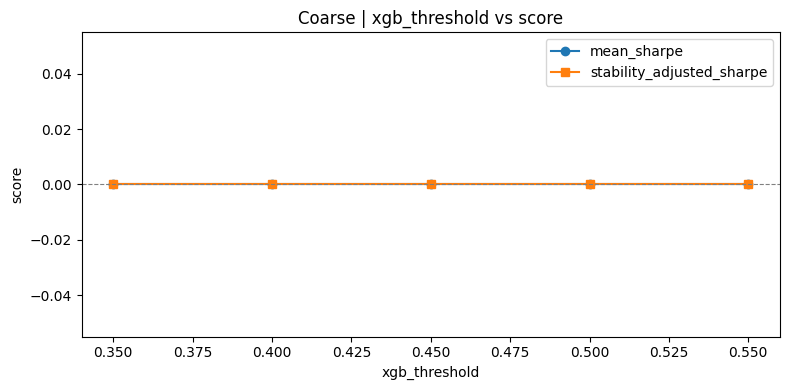

In [12]:
# -----------------------------
# Coarse pass
# -----------------------------

coarse_grid = build_coarse_grid()
print("Coarse combos:", len(coarse_grid))

coarse_results = run_grid_parallel(
    m5_df=m5_train,
    m15_df=m15_train,
    grid=coarse_grid,
    n_blocks=COARSE_CPCV_N_BLOCKS,
    k_val_blocks=COARSE_CPCV_K_VAL,
    embargo_bars=int(EMBARGO_HOURS * (BARS_PER_DAY["M5"] / 24.0)),
    n_jobs=N_JOBS,
)

coarse_results = coarse_results.sort_values(
    ["stability_adjusted_sharpe", "mean_sharpe"], ascending=False
).reset_index(drop=True)

coarse_results.to_csv("reports/strategy_plateau_coarse_m5.csv", index=False)

print("Top coarse results:")
display(
    coarse_results[
        [
            "xgb_threshold",
            "mean_sharpe_raw",
            "turnover_penalty",
            "mean_sharpe",
            "stability_adjusted_sharpe",
            "mean_trades_per_100",
            "n_paths",
            "median_trades",
        ]
    ].head(20)
)
plot_plateau_heatmaps(coarse_results, title_prefix="Coarse")


Fine combos: 15
Parallel backend=loky | n_jobs=7


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 out of  15 | elapsed:   48.0s remaining:  2.2min
[Parallel(n_jobs=7)]: Done   6 out of  15 | elapsed:  1.2min remaining:  1.8min
[Parallel(n_jobs=7)]: Done   8 out of  15 | elapsed:  1.5min remaining:  1.3min
[Parallel(n_jobs=7)]: Done  10 out of  15 | elapsed:  1.6min remaining:   47.0s
[Parallel(n_jobs=7)]: Done  12 out of  15 | elapsed:  1.6min remaining:   23.5s
[Parallel(n_jobs=7)]: Done  15 out of  15 | elapsed:  2.1min finished


Grid complete in 2.1 minutes
Top fine results:


,xgb_threshold,mean_sharpe_raw,turnover_penalty,mean_sharpe,stability_adjusted_sharpe,mean_trades_per_100,n_paths,median_trades
0,0.31,0.0,0.0,0.0,0.0,0.0,6,0
1,0.33,0.0,0.0,0.0,0.0,0.0,6,0
2,0.35,0.0,0.0,0.0,0.0,0.0,6,0
3,0.36,0.0,0.0,0.0,0.0,0.0,6,0
4,0.37,0.0,0.0,0.0,0.0,0.0,6,0
5,0.38,0.0,0.0,0.0,0.0,0.0,6,0
6,0.39,0.0,0.0,0.0,0.0,0.0,6,0
7,0.40,0.0,0.0,0.0,0.0,0.0,6,0
8,0.41,0.0,0.0,0.0,0.0,0.0,6,0
9,0.42,0.0,0.0,0.0,0.0,0.0,6,0


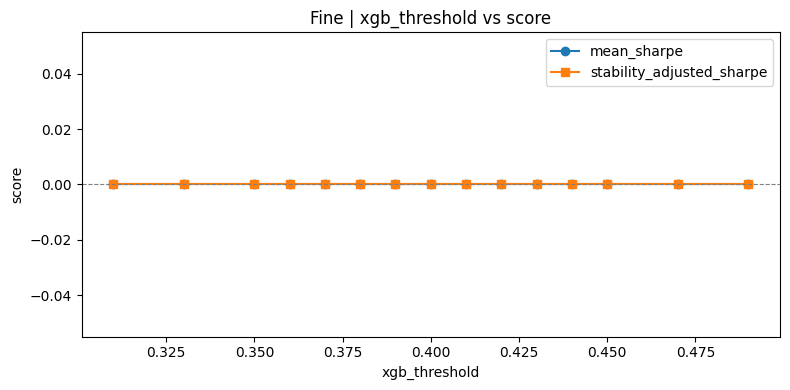

In [13]:
# -----------------------------
# Fine pass around top plateaus
# -----------------------------

fine_grid = build_refined_grid_from_top(coarse_results, top_k=3)
print("Fine combos:", len(fine_grid))

fine_results = run_grid_parallel(
    m5_df=m5_train,
    m15_df=m15_train,
    grid=fine_grid,
    n_blocks=FINE_CPCV_N_BLOCKS,
    k_val_blocks=FINE_CPCV_K_VAL,
    embargo_bars=int(EMBARGO_HOURS * (BARS_PER_DAY["M5"] / 24.0)),
    n_jobs=N_JOBS,
)

fine_results = fine_results.sort_values(
    ["stability_adjusted_sharpe", "mean_sharpe"], ascending=False
).reset_index(drop=True)

fine_results.to_csv("reports/strategy_plateau_fine_m5.csv", index=False)

print("Top fine results:")
display(
    fine_results[
        [
            "xgb_threshold",
            "mean_sharpe_raw",
            "turnover_penalty",
            "mean_sharpe",
            "stability_adjusted_sharpe",
            "mean_trades_per_100",
            "n_paths",
            "median_trades",
        ]
    ].head(20)
)
plot_plateau_heatmaps(fine_results, title_prefix="Fine")


In [14]:
# -----------------------------
# Sanity checks
# -----------------------------

print("Fine unique n_paths:", sorted(fine_results["n_paths"].dropna().unique().tolist()))
print("Fine mean trades/100 (top 10):", fine_results["mean_trades_per_100"].head(10).round(3).tolist())
print("Fine turnover penalty (top 10):", fine_results["turnover_penalty"].head(10).round(3).tolist())

print("\nTop 10 with raw vs penalized:")
display(
    fine_results[
        [
            "xgb_threshold",
            "mean_sharpe_raw",
            "turnover_penalty",
            "mean_sharpe",
            "stability_adjusted_sharpe",
            "mean_trades_per_100",
        ]
    ].head(10)
)

Fine unique n_paths: [6]
Fine mean trades/100 (top 10): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Fine turnover penalty (top 10): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Top 10 with raw vs penalized:


,xgb_threshold,mean_sharpe_raw,turnover_penalty,mean_sharpe,stability_adjusted_sharpe,mean_trades_per_100
0,0.31,0.0,0.0,0.0,0.0,0.0
1,0.33,0.0,0.0,0.0,0.0,0.0
2,0.35,0.0,0.0,0.0,0.0,0.0
3,0.36,0.0,0.0,0.0,0.0,0.0
4,0.37,0.0,0.0,0.0,0.0,0.0
5,0.38,0.0,0.0,0.0,0.0,0.0
6,0.39,0.0,0.0,0.0,0.0,0.0
7,0.40,0.0,0.0,0.0,0.0,0.0
8,0.41,0.0,0.0,0.0,0.0,0.0
9,0.42,0.0,0.0,0.0,0.0,0.0


In [15]:
# -----------------------------
# Final model selection + IS/OOS validation
# -----------------------------

def _normalize_metrics(met: dict, ending_balance: float) -> dict:
    out = dict(met)
    out["max_drawdown_pct"] = float(met.get("max_drawdown", met.get("max_drawdown_pct", 0.0)))
    out["n_trades"] = int(met.get("trade_count", met.get("n_trades", 0)))
    out["ending_balance_cents"] = float(ending_balance)
    return out


def run_ml_backtest_segment(m5_seg: pd.DataFrame, m15_seg: pd.DataFrame, exec_tf: str, xgb_threshold: float):
    tf = exec_tf.upper()
    if ML_TARGET_PARAMS.get(tf) is None:
        raise RuntimeError(f"No bridge baseline for {tf}")

    base_params = dict(ML_TARGET_PARAMS[tf]["parameters"])
    base_params["exit_model"] = ML_TARGET_PARAMS[tf]["exit_model"]

    feat = build_features(m5_seg, m15_seg, tf)
    hmm_cols = hmm_feature_columns(feat)
    model = HMMXGBComposite(random_state=RANDOM_STATE)
    model.fit(feat, feat["tb_label"], hmm_features=hmm_cols)
    probs = model.predict_proba_raw(feat)
    trades, met = run_ml_filtered_backtest(tf, feat, probs, base_params, float(xgb_threshold))
    ending_balance = float(INITIAL_BALANCE_CENTS + met.get("net_profit", 0.0))
    return trades, _normalize_metrics(met, ending_balance)


best_center = select_plateau_center(fine_results, min_mean_sharpe=-1e9)
print("Selected plateau center:")
print(best_center)

if best_center is None:
    d = fine_results.copy()
    d = d[np.isfinite(d["mean_sharpe"]) & np.isfinite(d["stability_adjusted_sharpe"])]
    if d.empty:
        raise RuntimeError("No valid fine results after filtering.")
    row = d.sort_values(["stability_adjusted_sharpe", "mean_sharpe"], ascending=False).iloc[0]
    best_center = {
        "xgb_threshold": float(row["xgb_threshold"]),
        "mean_sharpe": float(row["mean_sharpe"]),
        "mean_sharpe_raw": float(row.get("mean_sharpe_raw", np.nan)),
        "variance_sharpe": float(row["variance_sharpe"]),
        "stability_adjusted_sharpe": float(row["stability_adjusted_sharpe"]),
        "turnover_penalty": float(row.get("turnover_penalty", 0.0)),
        "mean_trades_per_100": float(row.get("mean_trades_per_100", np.nan)),
        "plateau_width_local": 0,
        "selection_score": float(row["stability_adjusted_sharpe"]),
    }
    print("Fallback center selected:")
    print(best_center)

best_xgb_threshold = float(best_center["xgb_threshold"])
best_params = {"xgb_threshold": best_xgb_threshold}

trades_is, met_is = run_ml_backtest_segment(m5_train, m15_train, EXEC_TF, best_xgb_threshold)
trades_oos, met_oos = run_ml_backtest_segment(m5_oos, m15_oos, EXEC_TF, best_xgb_threshold)

score_is = score_metrics(met_is)
score_oos = score_metrics(met_oos)

rel_drop = (score_is - score_oos) / (abs(score_is) + 1e-9)

summary = pd.DataFrame(
    [
        {
            "scenario": "IS",
            "score": score_is,
            "win_rate": met_is["win_rate"],
            "profit_factor": met_is["profit_factor"],
            "max_drawdown_pct": met_is["max_drawdown_pct"],
            "n_trades": met_is["n_trades"],
            "ending_balance_cents": met_is["ending_balance_cents"],
            "net_return_pct": met_is["net_return_pct"],
        },
        {
            "scenario": "OOS",
            "score": score_oos,
            "win_rate": met_oos["win_rate"],
            "profit_factor": met_oos["profit_factor"],
            "max_drawdown_pct": met_oos["max_drawdown_pct"],
            "n_trades": met_oos["n_trades"],
            "ending_balance_cents": met_oos["ending_balance_cents"],
            "net_return_pct": met_oos["net_return_pct"],
        },
    ]
)

print("\nBest params:")
print(best_params)

print("\nValidation summary:")
display(summary)

print(f"Relative score drop IS->OOS: {rel_drop:.2%}")
if rel_drop > 0.30:
    print("Warning: OOS drop exceeds 30%. Review thresholds or split stability.")

print("\nRecent OOS trades:")
if len(trades_oos) > 0:
    display(trades_oos.tail(20))
else:
    print("No OOS trades generated.")


Selected plateau center:
{'xgb_threshold': 0.31, 'mean_sharpe': 0.0, 'mean_sharpe_raw': 0.0, 'variance_sharpe': 0.0, 'stability_adjusted_sharpe': 0.0, 'turnover_penalty': 0.0, 'mean_trades_per_100': 0.0, 'plateau_width_local': 0, 'selection_score': 0.0}


ValueError: could not convert string to float: 'SHOCK'

In [ ]:
# -----------------------------
# Dual timeframe validation (one run): M15-only and M5-only
# -----------------------------

required = ["m5_all", "m15_all", "run_ml_backtest_segment", "score_metrics"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects before dual-timeframe run: {missing}")

if "best_params" in globals() and isinstance(best_params, dict) and "xgb_threshold" in best_params:
    run_threshold = float(best_params["xgb_threshold"])
elif "best_center" in globals() and isinstance(best_center, dict) and "xgb_threshold" in best_center:
    run_threshold = float(best_center["xgb_threshold"])
else:
    raise RuntimeError("best_params or best_center with xgb_threshold not found. Run final selection cell first.")


def split_exec_trend(exec_all: pd.DataFrame, trend_all: pd.DataFrame, holdout_frac: float):
    exec_all = exec_all.sort_index().copy()
    trend_all = trend_all.sort_index().copy()

    if len(exec_all) < 1000:
        raise RuntimeError(f"Not enough rows for split. Got {len(exec_all)} rows.")

    split_idx = int(len(exec_all) * (1.0 - holdout_frac))
    split_idx = max(500, min(split_idx, len(exec_all) - 1))

    exec_is = exec_all.iloc[:split_idx].copy()
    exec_oos = exec_all.iloc[split_idx:].copy()

    split_time = exec_is.index[-1]
    trend_is = trend_all.loc[trend_all.index <= split_time].copy()
    trend_oos = trend_all.loc[trend_all.index > split_time].copy()

    return exec_is, exec_oos, trend_is, trend_oos, split_time


def run_mode(mode_name: str, exec_all: pd.DataFrame, trend_all: pd.DataFrame, exec_tf: str, xgb_threshold: float):
    exec_is, exec_oos, trend_is, trend_oos, split_time = split_exec_trend(
        exec_all=exec_all,
        trend_all=trend_all,
        holdout_frac=HOLDOUT_FRAC,
    )

    trades_is, met_is = run_ml_backtest_segment(exec_is, trend_is, exec_tf, xgb_threshold)
    score_is = score_metrics(met_is)

    trades_oos, met_oos = run_ml_backtest_segment(exec_oos, trend_oos, exec_tf, xgb_threshold)
    score_oos = score_metrics(met_oos)

    rel_drop = float((score_is - score_oos) / (abs(score_is) + 1e-9))

    rows = [
        {
            "timeframe_mode": mode_name,
            "scenario": "IS",
            "xgb_threshold": float(xgb_threshold),
            "score": float(score_is),
            "win_rate": float(met_is["win_rate"]),
            "profit_factor": float(met_is["profit_factor"]),
            "max_drawdown_pct": float(met_is["max_drawdown_pct"]),
            "n_trades": int(met_is["n_trades"]),
            "ending_balance_cents": float(met_is["ending_balance_cents"]),
            "net_return_pct": float(met_is["net_return_pct"]),
            "relative_score_drop_is_to_oos": rel_drop,
            "split_time": split_time,
            "exec_rows": int(len(exec_is)),
            "trend_rows": int(len(trend_is)),
        },
        {
            "timeframe_mode": mode_name,
            "scenario": "OOS",
            "xgb_threshold": float(xgb_threshold),
            "score": float(score_oos),
            "win_rate": float(met_oos["win_rate"]),
            "profit_factor": float(met_oos["profit_factor"]),
            "max_drawdown_pct": float(met_oos["max_drawdown_pct"]),
            "n_trades": int(met_oos["n_trades"]),
            "ending_balance_cents": float(met_oos["ending_balance_cents"]),
            "net_return_pct": float(met_oos["net_return_pct"]),
            "relative_score_drop_is_to_oos": rel_drop,
            "split_time": split_time,
            "exec_rows": int(len(exec_oos)),
            "trend_rows": int(len(trend_oos)),
        },
    ]

    return rows, trades_is, trades_oos


all_rows = []
trades_by_mode = {}

rows_m15, t_m15_is, t_m15_oos = run_mode(
    mode_name="M15_only",
    exec_all=m15_all,
    trend_all=m15_all,
    exec_tf="M15",
    xgb_threshold=run_threshold,
)
all_rows.extend(rows_m15)
trades_by_mode["M15_only_IS"] = t_m15_is
trades_by_mode["M15_only_OOS"] = t_m15_oos

rows_m5, t_m5_is, t_m5_oos = run_mode(
    mode_name="M5_only",
    exec_all=m5_all,
    trend_all=m15_all,
    exec_tf="M5",
    xgb_threshold=run_threshold,
)
all_rows.extend(rows_m5)
trades_by_mode["M5_only_IS"] = t_m5_is
trades_by_mode["M5_only_OOS"] = t_m5_oos

dual_tf_summary = pd.DataFrame(all_rows)
dual_tf_summary["scenario_order"] = dual_tf_summary["scenario"].map({"IS": 0, "OOS": 1})
dual_tf_summary = dual_tf_summary.sort_values(["timeframe_mode", "scenario_order"]).drop(columns=["scenario_order"])

print("Threshold used for both timeframe runs:")
print(run_threshold)

print("\nDual timeframe summary:")
display(dual_tf_summary)

print("\nSide-by-side compact view:")
dual_tf_compact = dual_tf_summary.pivot_table(
    index="timeframe_mode",
    columns="scenario",
    values=["score", "win_rate", "profit_factor", "max_drawdown_pct", "n_trades", "net_return_pct"],
    aggfunc="first",
)
display(dual_tf_compact)

dual_tf_summary.to_csv("reports/dual_tf_is_oos_summary.csv", index=False)
print("\nSaved: reports/dual_tf_is_oos_summary.csv")


In [ ]:
# -----------------------------
# Optional live risk circuit breaker prototype
# -----------------------------

from scipy.stats import entropy

class ProductionRiskCircuitBreaker:
    def __init__(self, historical_mean_sharpe, historical_min_sharpe, max_allowed_slippage_pips=2.5):
        self.hist_mean_sharpe = float(historical_mean_sharpe)
        self.hist_min_sharpe = float(historical_min_sharpe)
        self.max_slippage = float(max_allowed_slippage_pips)

        self.trade_returns = []
        self.trade_slippages = []
        self.hmm_state_probabilities = []

    def log_executed_trade(self, return_pct, slippage_pips, hmm_proba_vector):
        self.trade_returns.append(float(return_pct))
        self.trade_slippages.append(float(slippage_pips))
        self.hmm_state_probabilities.append(np.array(hmm_proba_vector, dtype=float))

    def calculate_rolling_sharpe(self, window=30):
        if len(self.trade_returns) < window:
            return self.hist_mean_sharpe
        r = np.array(self.trade_returns[-window:], dtype=float)
        return float((r.mean() / (r.std() + 1e-6)) * np.sqrt(252.0))

    def check_regime_drift(self, window=12):
        if len(self.hmm_state_probabilities) < window:
            return 0.0
        recent = self.hmm_state_probabilities[-window:]
        return float(np.mean([entropy(np.clip(p, 1e-12, 1.0)) for p in recent]))

    def evaluate_system_health(self):
        if len(self.trade_returns) < 15:
            return "GREEN", "Initialization phase"

        live_sharpe = self.calculate_rolling_sharpe(window=30)
        avg_slippage = float(np.mean(self.trade_slippages[-15:]))
        avg_entropy = self.check_regime_drift(window=12)

        if avg_slippage > self.max_slippage:
            return "RED", f"HALT: slippage {avg_slippage:.2f} exceeds limit"

        if live_sharpe < self.hist_min_sharpe:
            return "RED", f"HALT: live sharpe {live_sharpe:.2f} below minimum"

        if live_sharpe < (self.hist_mean_sharpe * 0.5) or avg_entropy > 1.2:
            return "YELLOW", f"WARN: decay or high entropy {avg_entropy:.2f}"

        return "GREEN", f"Healthy. live sharpe={live_sharpe:.2f}"